# Practical Experiments

This notebook covers two practical experiments:
1. Setting Up the Environment for Generative AI and making use of generative models for creative content generation.
2. Implementing simple probabilistic models like Gaussian Mixture Models.

## 1. Generative AI for Creative Content Generation

Using Hugging Face's `transformers` library, we load a GPT-2 model to generate creative text based on a starting prompt.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from transformers import pipeline

def generate_creative_content(prompt):
    print("Initializing generative model (GPT-2)...")
    # Using GPT-2, a popular and lightweight generative model for text
    generator = pipeline('text-generation', model='gpt2')
    
    print(f"\nGenerating content based on prompt: '{prompt}'")
    # Generate text
    results = generator(
        prompt,
        max_length=150,
        num_return_sequences=1,
        truncation=True,
        pad_token_id=50256 # EOS token id for GPT-2
    )
    
    print("\n--- Generated Content ---")
    print(results[0]['generated_text'])
    print("-------------------------\n")

# Test the generator
sample_prompt = "In a futuristic city where AI and humans coexist,"
generate_creative_content(sample_prompt)

Initializing generative model (GPT-2)...


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.



Generating content based on prompt: 'In a futuristic city where AI and humans coexist,'


[transformers] Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



--- Generated Content ---
In a futuristic city where AI and humans coexist, the first computer in two generations would be able to communicate intelligently with each other.

"We expect to see a big increase in people in the next few decades. A huge increase that would be of great interest to AI and humans as well as to computers," says Richard Leiter, head of AI at the University of Oxford.

The researchers suggest computers could also be used to take over human jobs and social work and even to make more money. "If human brains can be linked to computers, they could lead to a new kind of work for humans," says Leiter.

The idea for AI and humans comes from a recent study by the University of Sheffield. Dr James Cook, from Edinburgh University, said: "It's a question that the future will be about: how do we make the machines smarter and more efficient, and how do we use them to increase productivity and save money?"

He pointed out that some of the most important jobs would involve im

## 2. Gaussian Mixture Models (GMM)

Using `scikit-learn` to generate synthetic 2D data, fit a Gaussian Mixture Model to identify 3 clusters, and visualize the output using `matplotlib`.

Generating synthetic data...
Fitting Gaussian Mixture Model...


Visualizing results...


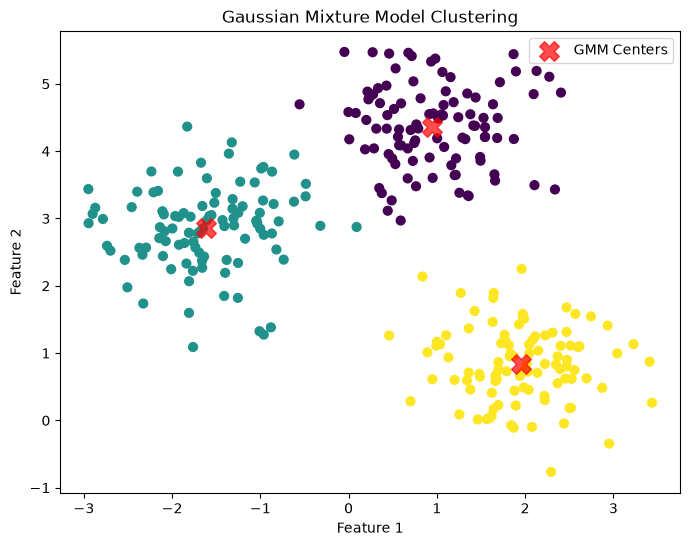

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

def implement_gmm():
    print("Generating synthetic data...")
    # Generate sample data: 3 clusters
    n_samples = 300
    X, y_true = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.60, random_state=0)
    
    print("Fitting Gaussian Mixture Model...")
    # Fit a Gaussian Mixture Model with 3 components
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm.fit(X)
    
    # Predict cluster labels
    labels = gmm.predict(X)
    
    print("Visualizing results...")
    # Plot the results
    plt.figure(figsize=(8, 6))
    
    # Scatter plot of the data points, colored by their predicted cluster
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    
    # Plot the cluster centers (means)
    centers = gmm.means_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', zorder=3, label='GMM Centers')
    
    plt.title('Gaussian Mixture Model Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    
    # Display the plot in the notebook
    plt.show()

implement_gmm()